# Encontro 8 — Regressão linear na prática

**Aluno — prática guiada e laboratório**

> **Ideia central:** construir um modelo significa transformar uma pergunta em uma sequência verificável de decisões.

Usaremos novamente a base **Automobile**, adotada no curso *Data Analysis with Python* da IBM. Cada linha representa um automóvel e `price` é o preço em **dólares americanos**.

**Ao final, você deverá conseguir:**

1. organizar as variáveis de entrada `X` e a variável alvo `y`;
2. separar treinamento e teste;
3. ajustar uma regressão linear simples;
4. produzir e interpretar previsões;
5. calcular MAE, MSE, RMSE e R²;
6. examinar erros de previsão;
7. construir e comparar uma regressão múltipla.

## Como usar este notebook

O início é uma prática guiada. Execute as células em ordem com **Shift + Enter**, observe as saídas e responda às perguntas em Markdown. Depois, complete o laboratório marcado com `TODO`.

Quando aparecer **Pare e interprete**, não avance imediatamente: escreva uma resposta usando o contexto do problema e as unidades das variáveis.

## 1. Ambiente e carregamento da base

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda valor: f"{valor:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

AZUL = "#147D92"
VERDE = "#2A8C67"
LARANJA = "#E99A32"
VERMELHO = "#D94B4B"
CINZA = "#5F6B7A"

In [2]:
COLUNAS_BRUTAS = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location",
    "wheel-base", "length", "width", "height", "curb-weight",
    "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
    "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]


def preparar_fallback(df_bruto):
    # Reproduz as decisões essenciais de preparação usadas nos encontros anteriores.
    df_trabalho = df_bruto.dropna(subset=["price"]).copy()
    for coluna in ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm"]:
        df_trabalho[coluna] = df_trabalho[coluna].fillna(df_trabalho[coluna].median())
    df_trabalho["num-of-doors"] = df_trabalho["num-of-doors"].fillna(
        df_trabalho["num-of-doors"].mode()[0]
    )
    df_trabalho["city-L/100km"] = 235 / df_trabalho["city-mpg"]
    return df_trabalho


candidatos = [
    Path("dados/automoveis_preparados.csv"),
    Path("automoveis_preparados.csv"),
    Path("../007/dados/automoveis_preparados.csv"),
    Path("../005/dados/automoveis_preparados.csv"),
]
caminho = next((arquivo for arquivo in candidatos if arquivo.exists()), None)

if caminho is not None:
    df = pd.read_csv(caminho)
    origem = str(caminho)
else:
    origem = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
    df_bruto = pd.read_csv(origem, names=COLUNAS_BRUTAS, na_values="?")
    df = preparar_fallback(df_bruto)

assert len(df) == 201, "A base preparada deveria possuir 201 automóveis."
assert df[["price", "horsepower", "curb-weight", "engine-size", "highway-mpg"]].isna().sum().sum() == 0

print("Origem:", origem)
print("Dimensões:", df.shape)
df[["horsepower", "curb-weight", "engine-size", "highway-mpg", "fuel-type", "body-style", "price"]].head()

Origem: dados/automoveis_preparados.csv
Dimensões: (201, 32)


,horsepower,curb-weight,engine-size,highway-mpg,fuel-type,body-style,price
0,111.00,2548,130,27,gas,convertible,"13,495.00"
1,111.00,2548,130,27,gas,convertible,"16,500.00"
2,154.00,2823,152,26,gas,hatchback,"16,500.00"
3,102.00,2337,109,30,gas,sedan,"13,950.00"
4,115.00,2824,136,22,gas,sedan,"17,450.00"


## 2. Da pergunta às variáveis

**Pergunta:** podemos estimar o preço de um automóvel a partir de suas características?

- `y = price`: variável alvo, em dólares americanos;
- `X`: características conhecidas antes da previsão;
- `ŷ`: preço previsto pelo modelo;
- `y - ŷ`: diferença entre observado e previsto.

Na regressão simples começaremos com `horsepower`. Depois acrescentaremos peso, tamanho do motor e consumo rodoviário.

In [3]:
colunas_aula = [
    "horsepower", "curb-weight", "engine-size", "highway-mpg",
    "fuel-type", "body-style", "price"
]
df[colunas_aula].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
horsepower,201.00,NaN,NaN,NaN,103.31,37.37,48.00,70.00,95.00,116.00,262.00
curb-weight,201.00,NaN,NaN,NaN,"2,555.67",517.30,"1,488.00","2,169.00","2,414.00","2,926.00","4,066.00"
engine-size,201.00,NaN,NaN,NaN,126.88,41.55,61.00,98.00,120.00,141.00,326.00
highway-mpg,201.00,NaN,NaN,NaN,30.69,6.82,16.00,25.00,30.00,34.00,54.00
fuel-type,201,2,gas,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body-style,201,5,sedan,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,201.00,NaN,NaN,NaN,"13,207.13","7,947.07","5,118.00","7,775.00","10,295.00","16,500.00","45,400.00"


<div style="border-left: 5px solid #E99A32; padding: 10px 14px; background: #FFF8E8; margin: 8px 0 14px 0;">
<strong>Vocabulário técnico</strong><br>
Nos dados usados para ajustar o modelo, a diferença <code>y - ŷ</code> é chamada de <strong>resíduo</strong> (<em>residual</em>). Em dados novos ou de teste, <strong>erro de previsão</strong> (<em>prediction error</em>) é o termo mais preciso. Em Machine Learning, a palavra erro também aparece como termo geral.
</div>

## 3. Antes do modelo: observe a relação

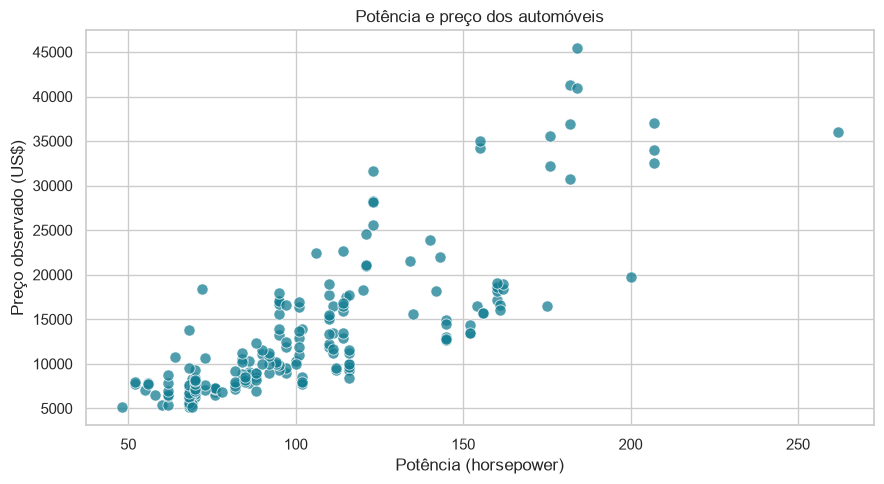

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="horsepower", y="price", color=AZUL, alpha=0.75, s=65, ax=ax)
ax.set(
    title="Potência e preço dos automóveis",
    xlabel="Potência (horsepower)",
    ylabel="Preço observado (US$)",
)
plt.tight_layout()
plt.show()

### Pare e interprete

1. A relação parece positiva ou negativa?
2. Os pontos formam uma reta perfeita?
3. Que outras características podem explicar o preço?

> **Sua resposta:** escreva aqui antes de continuar.

## 4. Prática guiada — regressão linear simples

Usaremos `horsepower` como única entrada e `price` como alvo:

\[
\widehat{price} = b_0 + b_1 \cdot horsepower
\]

In [5]:
X_simples = df[["horsepower"]]
y = df["price"]

X_treino_s, X_teste_s, y_treino_s, y_teste_s = train_test_split(
    X_simples,
    y,
    test_size=0.20,
    random_state=42,
)

print("Treinamento:", X_treino_s.shape, y_treino_s.shape)
print("Teste:", X_teste_s.shape, y_teste_s.shape)

Treinamento: (160, 1) (160,)
Teste: (41, 1) (41,)


### Pare e interprete

Por que o conjunto de teste deve permanecer separado enquanto o modelo aprende os coeficientes?

> **Sua resposta:** escreva aqui.

In [6]:
modelo_simples = LinearRegression()
modelo_simples.fit(X_treino_s, y_treino_s)

intercepto_s = modelo_simples.intercept_
inclinacao_s = modelo_simples.coef_[0]

print(f"Intercepto: {intercepto_s:,.2f}")
print(f"Inclinação: {inclinacao_s:,.2f} dólares por horsepower")
print(f"Equação: preço previsto = {intercepto_s:,.2f} + {inclinacao_s:,.2f} × horsepower")

Intercepto: -2,910.92
Inclinação: 152.10 dólares por horsepower
Equação: preço previsto = -2,910.92 + 152.10 × horsepower


### Pare e interprete

Explique a inclinação usando uma frase completa, com a unidade. O resultado prova que aumentar a potência causa o aumento do preço?

> **Sua resposta:** escreva aqui.

In [7]:
novo_carro = pd.DataFrame({"horsepower": [100]})
preco_novo = modelo_simples.predict(novo_carro)[0]
print(f"Preço previsto para um automóvel com 100 hp: US$ {preco_novo:,.2f}")

Preço previsto para um automóvel com 100 hp: US$ 12,298.95


### Pare e interprete

Por que o valor acima é uma estimativa e não uma garantia de venda?

> **Sua resposta:** escreva aqui.

In [8]:
def avaliar_regressao(nome, y_observado, y_previsto):
    # Retorna métricas de regressão em um formato fácil de comparar.
    mse = mean_squared_error(y_observado, y_previsto)
    return pd.Series({
        "modelo": nome,
        "MAE": mean_absolute_error(y_observado, y_previsto),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_observado, y_previsto),
    })

In [9]:
y_prev_treino_s = modelo_simples.predict(X_treino_s)
y_prev_teste_s = modelo_simples.predict(X_teste_s)

resultados_simples = pd.DataFrame({
    "observado": y_teste_s,
    "previsto": y_prev_teste_s,
})
resultados_simples["erro_previsao"] = resultados_simples["observado"] - resultados_simples["previsto"]
resultados_simples.head(8)

,observado,previsto,erro_previsao
95,"8,249.00","7,583.89",665.11
15,"41,315.00","24,771.05","16,543.95"
30,"6,855.00","8,648.58","-1,793.58"
158,"9,258.00","7,735.99","1,522.01"
128,"11,850.00","13,819.94","-1,969.94"
115,"5,572.00","7,431.79","-1,859.79"
69,"35,056.00","20,664.38","14,391.62"
171,"9,988.00","11,082.16","-1,094.16"


In [10]:
metricas_simples = pd.DataFrame([
    avaliar_regressao("simples_treino", y_treino_s, y_prev_treino_s),
    avaliar_regressao("simples_teste", y_teste_s, y_prev_teste_s),
]).set_index("modelo")
metricas_simples

,MAE,MSE,RMSE,R2
modelo,,,,
simples_treino,"2,863.60","16,227,197.87","4,028.30",0.64
simples_teste,"4,809.17","45,964,568.17","6,779.72",0.62


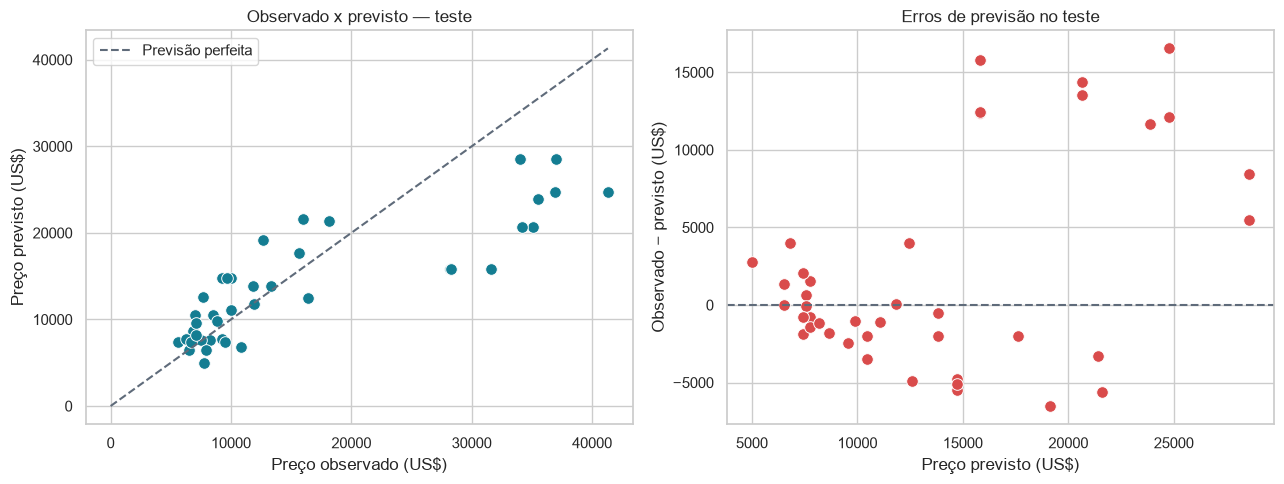

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

limite = max(resultados_simples["observado"].max(), resultados_simples["previsto"].max())
sns.scatterplot(data=resultados_simples, x="observado", y="previsto", color=AZUL, s=70, ax=axes[0])
axes[0].plot([0, limite], [0, limite], linestyle="--", color=CINZA, label="Previsão perfeita")
axes[0].set(title="Observado x previsto — teste", xlabel="Preço observado (US$)", ylabel="Preço previsto (US$)")
axes[0].legend()

sns.scatterplot(data=resultados_simples, x="previsto", y="erro_previsao", color=VERMELHO, s=70, ax=axes[1])
axes[1].axhline(0, linestyle="--", color=CINZA)
axes[1].set(title="Erros de previsão no teste", xlabel="Preço previsto (US$)", ylabel="Observado − previsto (US$)")

plt.tight_layout()
plt.show()

### Pare e interprete

1. Qual é o MAE de teste e como ele pode ser explicado em dólares?
2. Por que o RMSE é maior que o MAE?
3. O que o R² de teste informa?
4. Os erros parecem distribuídos aleatoriamente ao redor de zero?

> **Suas respostas:** escreva aqui.

## 5. Laboratório — construa uma regressão múltipla

Agora você assumirá a construção do modelo. Use inicialmente estas quatro variáveis para que os resultados possam ser comparados entre os grupos:

- `horsepower`;
- `curb-weight`;
- `engine-size`;
- `highway-mpg`.

### Etapa 1 — organize `X`, separe treino e teste

Use `random_state=42` e `test_size=0.20`.

In [12]:
# TODO 1
# 1. Crie a lista variaveis_multiplas.
# 2. Crie X_multiplo com essas colunas.
# 3. Use train_test_split() para criar X_treino_m, X_teste_m, y_treino_m e y_teste_m.

### Etapa 2 — ajuste o modelo

Crie `modelo_multiplo`, execute `fit()` e mostre intercepto e coeficientes em um DataFrame.

In [13]:
# TODO 2
# modelo_multiplo = ...
# modelo_multiplo.fit(...)
# coeficientes_multiplo = pd.DataFrame(...)

### Etapa 3 — produza previsões e métricas

Calcule previsões para treinamento e teste. Depois use `avaliar_regressao()` e compare o modelo múltiplo com `metricas_simples`.

In [14]:
# TODO 3
# y_prev_treino_m = ...
# y_prev_teste_m = ...
# metricas_multiplo = ...
# comparacao_modelos = ...

### Etapa 4 — examine os erros

Crie uma tabela com `observado`, `previsto` e `erro_previsao`. Produza:

1. observado × previsto, com uma diagonal de referência;
2. previsto × erro de previsão, com uma linha horizontal em zero.

In [15]:
# TODO 4
# resultados_multiplo = pd.DataFrame(...)
# resultados_multiplo["erro_previsao"] = ...
# Crie os dois gráficos.

### Etapa 5 — interpretação final

Responda usando números produzidos pelo seu notebook:

1. O modelo múltiplo reduziu o MAE de teste? Quanto?
2. O R² de teste aumentou?
3. Qual coeficiente parece maior em valor absoluto? As unidades permitem comparar coeficientes diretamente?
4. Os erros exibem algum padrão?
5. Qual modelo você apresentaria e com qual limitação?

> **Suas respostas:** escreva aqui.

## 6. Desafio opcional — acrescente categorias com um pipeline

Use `fuel-type` e `body-style` junto às variáveis numéricas. O `OneHotEncoder` deve ficar dentro de um `ColumnTransformer`, e o transformador deve ficar dentro de um `Pipeline` com `LinearRegression`.

In [16]:
# TODO OPCIONAL
# numericas = [...]
# categoricas = [...]
# X_completo = ...
# preparação = ColumnTransformer([...])
# pipeline_completo = Pipeline([...])
# Ajuste, preveja e compare as métricas de teste.

## 7. Entrega

In [17]:
# TODO 5 — exportação
# Crie uma pasta chamada entregas e salve nela:
# 1. comparacao_modelos.csv
# 2. coeficientes_modelo_multiplo.csv
# 3. previsoes_teste_modelo_multiplo.csv

### Checklist

- [ ] Executei todas as células sem erro.
- [ ] Mantive o conjunto de teste separado do treinamento.
- [ ] Interpretei a inclinação com unidade e contexto.
- [ ] Calculei MAE, MSE, RMSE e R² no teste.
- [ ] Comparei regressão simples e múltipla.
- [ ] Examinei os erros em um gráfico.
- [ ] Registrei pelo menos uma limitação.
- [ ] Exportei os três arquivos solicitados.

## Síntese

Complete:

1. O modelo aprende os coeficientes usando os dados de __________.
2. O conjunto de __________ simula exemplos que o modelo ainda não viu.
3. Em dados novos, `y - ŷ` é um __________ de previsão.
4. Um MAE de 3.000 significa um erro absoluto médio de aproximadamente __________.
5. Um R² alto não prova __________.